In [1]:
!pip install seaborn

In [2]:
!pip install folium

In [5]:
!pip install js

  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for js: filename=js-1.0-py3-none-any.whl size=2899 sha256=755eac073cf79a9a25a9288ff9f36ee6e4ec098b90301c2f74cc34ee329314a7
  Stored in directory: c:\users\e a p\appdata\local\pip\cache\wheels\36\ef\97\22589ad7139b0b24351f1e84763d4b2fd2d29e1f3db425f697
Successfully built js


In [7]:
import numpy as np
import pandas as pd
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import folium
import js

In [12]:
import requests
import io

URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DV0101EN-SkillsNetwork/Data%20Files/historical_automobile_sales.csv"
resp = requests.get(URL)
text = io.StringIO(resp.text)
import pandas as pd    
df = pd.read_csv(text)
print('Data downloaded and read into a dataframe!')


Data downloaded and read into a dataframe!


In [13]:
df.describe()

,Year,Recession,Consumer_Confidence,Seasonality_Weight,Price,Advertising_Expenditure,Competition,GDP,Growth_Rate,unemployment_rate,Automobile_Sales
count,528.000000,528.000000,528.000000,528.000000,528.000000,528.000000,528.000000,528.000000,528.000000,528.000000,528.000000
mean,2001.500000,0.214015,101.140170,0.575795,24964.991956,3067.456439,6.064394,40.073903,-0.242001,2.453977,2352.718068
std,12.710467,0.410526,10.601154,0.454477,4888.073433,1139.564637,1.968350,16.249714,0.861268,1.119019,1645.321284
min,1980.000000,0.000000,73.900000,0.000000,8793.663000,1009.000000,3.000000,12.508000,-4.227601,1.000000,102.000000
25%,1990.750000,0.000000,94.035000,0.250000,21453.300500,2083.500000,4.000000,27.237500,-0.574049,1.600000,793.950000
50%,2001.500000,0.000000,100.740000,0.500000,25038.691500,3072.000000,6.000000,39.214500,-0.013162,2.300000,2182.600000
75%,2012.250000,0.000000,108.240000,0.750000,28131.684750,4067.250000,8.000000,53.506500,0.388932,2.900000,3614.800000
max,2023.000000,1.000000,131.670000,1.500000,44263.657000,4983.000000,9.000000,70.374000,0.815074,6.000000,21147.000000


In [14]:
df.columns

Index(['Date', 'Year', 'Month', 'Recession', 'Consumer_Confidence',
       'Seasonality_Weight', 'Price', 'Advertising_Expenditure', 'Competition',
       'GDP', 'Growth_Rate', 'unemployment_rate', 'Automobile_Sales',
       'Vehicle_Type', 'City'],
      dtype='object')

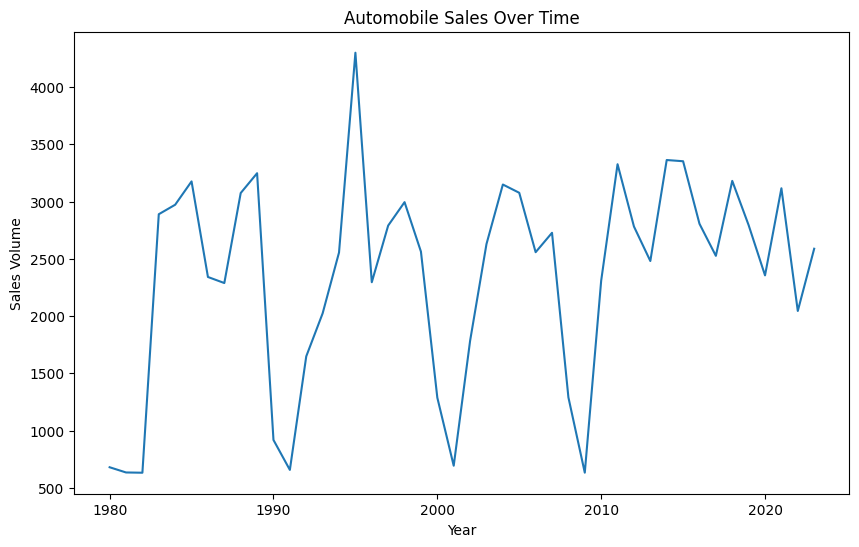

In [15]:
plt.figure(figsize = (10,6))
df_line = df.groupby('Year')['Automobile_Sales'].mean()
df_line.plot(kind='line',x=df_line.index,y=df_line.values)
plt.xlabel('Year')
plt.ylabel('Sales Volume')
plt.title('Automobile Sales Over Time')
plt.show()

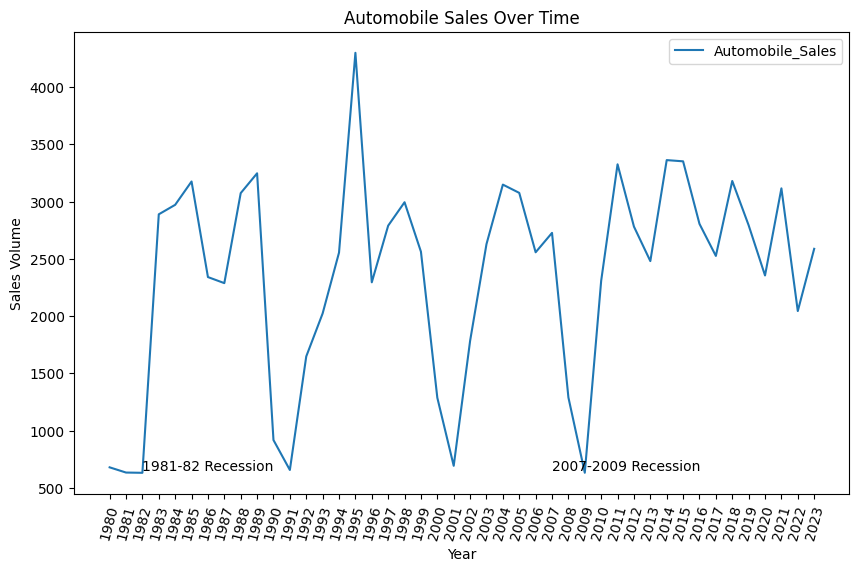

In [16]:
plt.figure(figsize =(10,6))
df_line = df.groupby('Year')['Automobile_Sales'].mean()
df_line.plot(kind='line',x=df_line.index,y=df_line.values)
plt.xticks(list(range(1980,2024)), rotation = 75)
plt.xlabel('Year')
plt.ylabel('Sales Volume')
plt.title('Automobile Sales Over Time')
plt.text(1982, 650, '1981-82 Recession')
plt.text(2007,650, '2007-2009 Recession')
plt.legend()
plt.show()

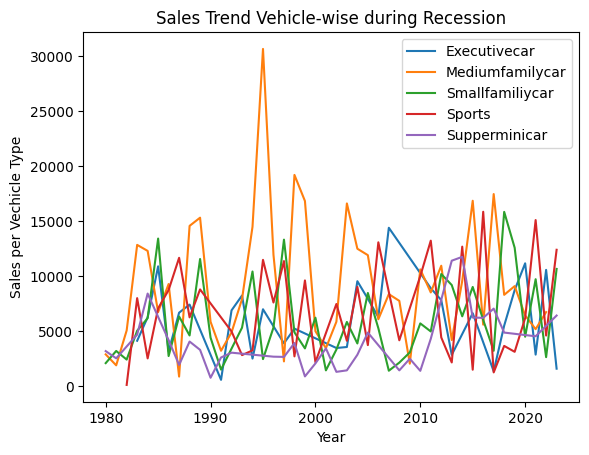

In [17]:
df_Mline = df.groupby(['Year','Vehicle_Type'], as_index=False)['Automobile_Sales'].sum()
df_Mline.set_index('Year', inplace=True)
df_Mline = df_Mline.groupby(['Vehicle_Type'])['Automobile_Sales']
df_Mline.plot(kind='line')
plt.xlabel('Year')
plt.ylabel('Sales per Vechicle Type')
plt.title('Sales Trend Vehicle-wise during Recession')
plt.legend()
plt.show()

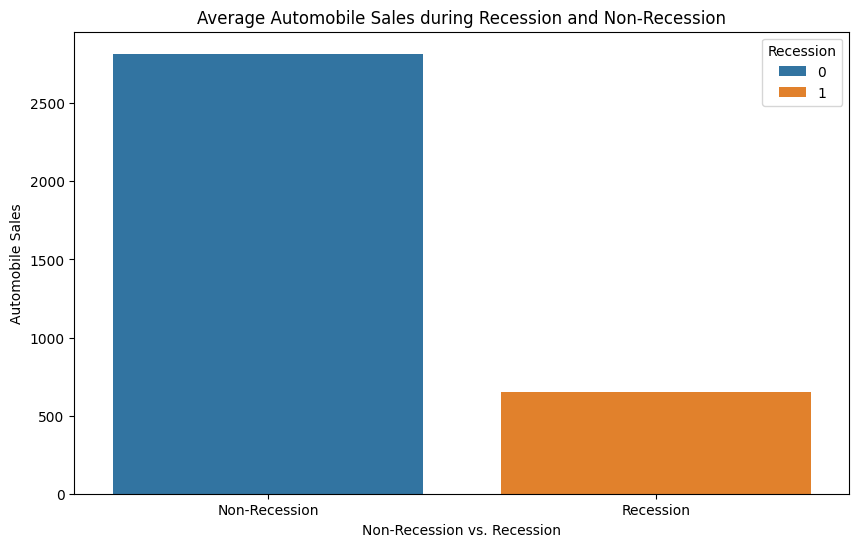

In [18]:
new_df = df.groupby('Recession')['Automobile_Sales'].mean().reset_index()

plt.figure(figsize=(10,6))
sns.barplot(x='Recession',y='Automobile_Sales', hue='Recession', data = new_df)
plt.xlabel('Non-Recession vs. Recession')
plt.ylabel('Automobile Sales')
plt.title('Average Automobile Sales during Recession and Non-Recession')
plt.xticks(ticks=[0,1], labels =['Non-Recession','Recession'])
plt.show()

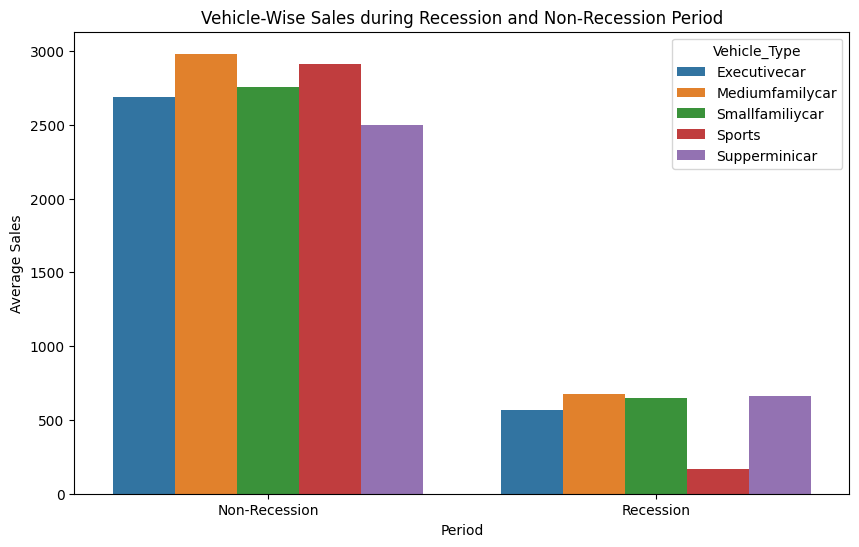

In [19]:
recession_data = df[df['Recession'] == 1]

group_data=df.groupby(['Recession','Vehicle_Type'])['Automobile_Sales'].mean().reset_index()

    
sales_by_vehicle_type = recession_data.groupby('Vehicle_Type')['Automobile_Sales'].sum().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(x='Recession', y='Automobile_Sales', hue='Vehicle_Type', data=group_data)
plt.xticks(ticks=[0, 1], labels=['Non-Recession', 'Recession'])
plt.xlabel('Period')
plt.ylabel('Average Sales')
plt.title('Vehicle-Wise Sales during Recession and Non-Recession Period')

plt.show()

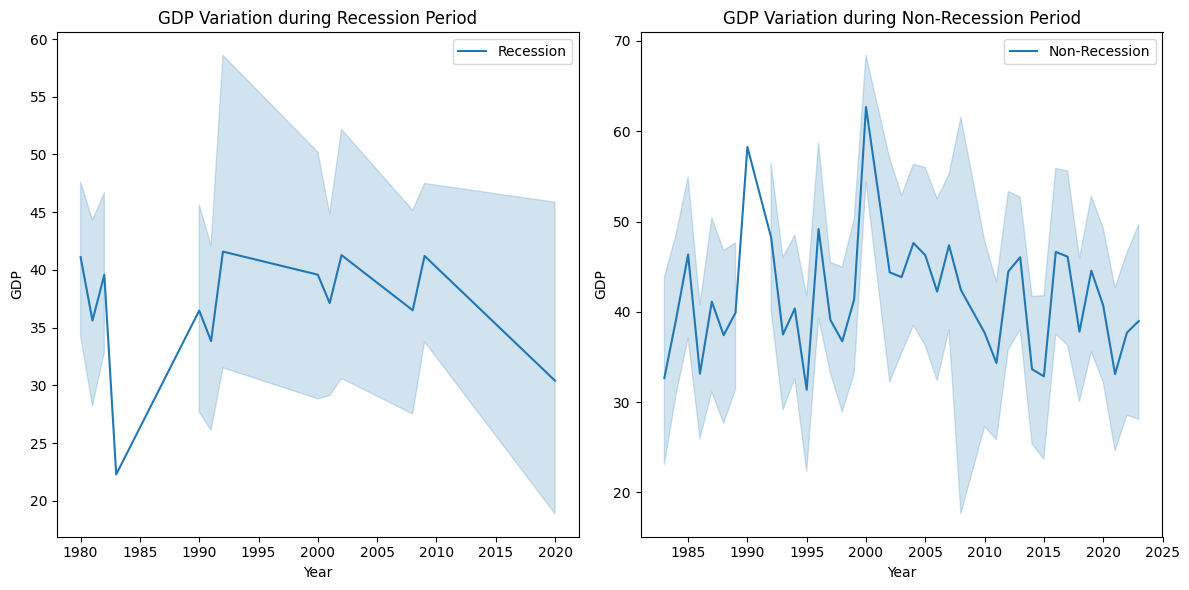

In [20]:
recession_data = df[df['Recession'] ==1]
non_recession_data = df[df['Recession']== 0]

figure = plt.figure(figsize=(12,6))

ax = figure.add_subplot(1,2,1)
ax1 = figure.add_subplot(1,2,2)

plt.subplot(1,2,1)
sns.lineplot(x='Year',y='GDP', data = recession_data, label='Recession', ax = ax)
ax.set_xlabel('Year')
ax.set_ylabel('GDP')
ax.set_title('GDP Variation during Recession Period')

plt.subplot(1,2,2)
sns.lineplot(x='Year',y='GDP', data = non_recession_data, label='Non-Recession', ax = ax1)
ax1.set_xlabel('Year')
ax1.set_ylabel('GDP')
ax1.set_title('GDP Variation during Non-Recession Period')

plt.tight_layout()
plt.show()

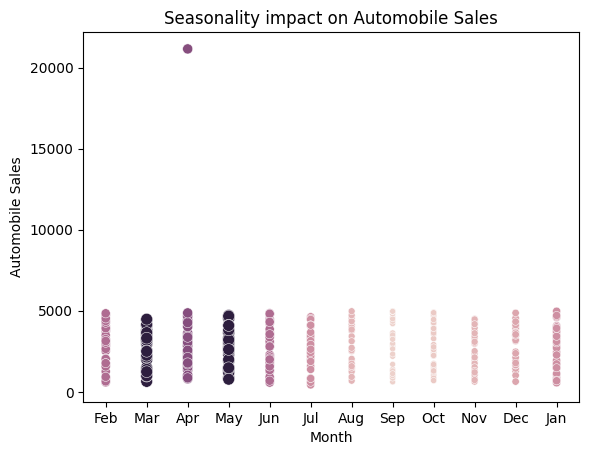

In [21]:
non_recession_data = df[df['Recession']== 0]

size = non_recession_data['Seasonality_Weight']

sns.scatterplot(data= non_recession_data, x='Month',y='Automobile_Sales',size=size,hue ='Seasonality_Weight', legend=False)

plt.xlabel('Month')
plt.ylabel('Automobile Sales')
plt.title('Seasonality impact on Automobile Sales')

plt.show()

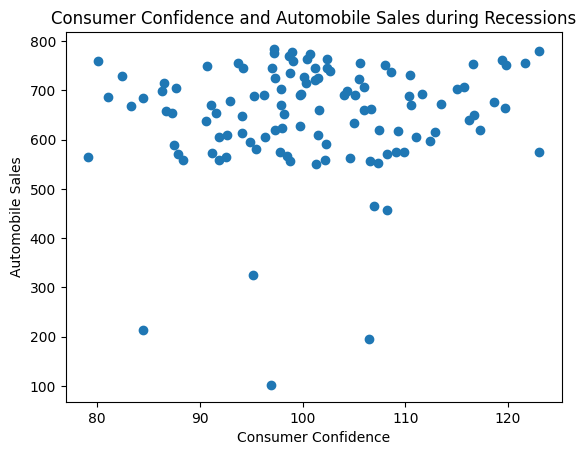

In [22]:
recession_data1 = df[df['Recession'] == 1]
non_recession_data1 = df[df['Recession']== 0]

plt.scatter(recession_data['Consumer_Confidence'],recession_data1['Automobile_Sales'])
            
plt.xlabel('Consumer Confidence')
plt.ylabel('Automobile Sales')
plt.title('Consumer Confidence and Automobile Sales during Recessions')
plt.show()

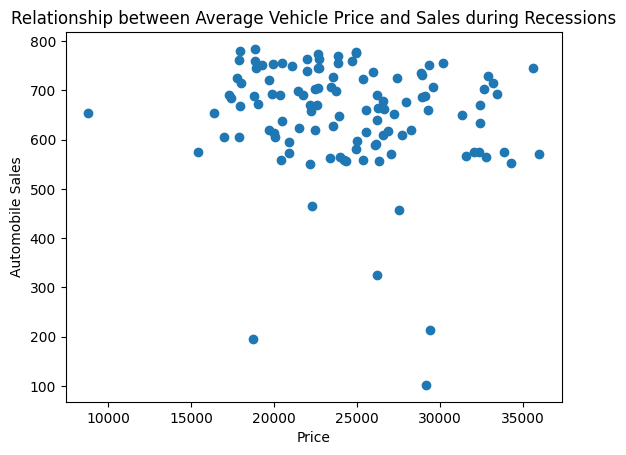

In [23]:
recession_data1 = df[df['Recession'] == 1]
non_recession_data = df[df['Recession']== 0]

plt.scatter(recession_data['Price'],recession_data1['Automobile_Sales'])
            
plt.xlabel('Price')
plt.ylabel('Automobile Sales')
plt.title('Relationship between Average Vehicle Price and Sales during Recessions')
plt.show()

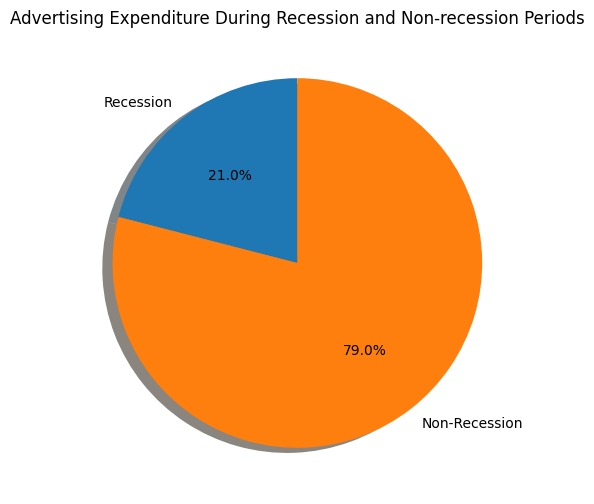

In [24]:
recession_data2 = df[df['Recession'] == 1]
non_recession_data2 = df[df['Recession']== 0]

recession_total = recession_data2['Advertising_Expenditure'].sum()
non_recession_total = non_recession_data2['Advertising_Expenditure'].sum()

plt.figure(figsize=(8,6))

labels = ['Recession','Non-Recession']
sizes = [recession_total,non_recession_total]
plt.pie(sizes, labels = labels, autopct='%1.1f%%',
        shadow={'ox': -0.04, 'edgecolor': 'none', 'shade': 0.9},startangle=90)

plt.title('Advertising Expenditure During Recession and Non-recession Periods')

plt.show()

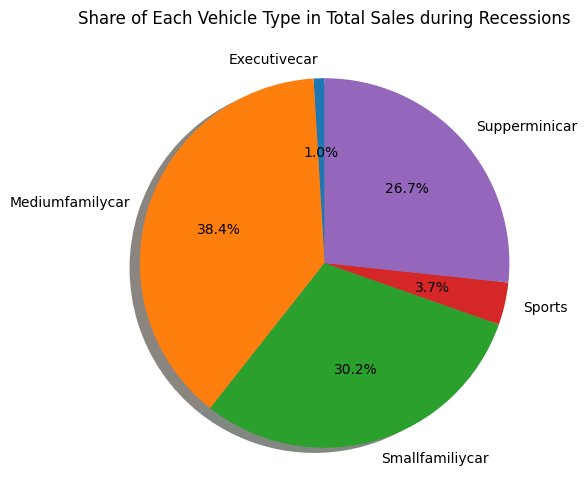

In [25]:
recession_data3 = df[df['Recession'] == 1]

Vec_sales = recession_data3.groupby('Vehicle_Type')['Advertising_Expenditure'].sum()

plt.figure(figsize=(8,6))

labels = Vec_sales.index
sizes = Vec_sales.values
plt.pie(sizes, labels = labels, autopct='%1.1f%%',
        shadow={'ox': -0.04, 'edgecolor': 'none', 'shade': 0.9},startangle=90)

plt.title('Share of Each Vehicle Type in Total Sales during Recessions')

plt.show()

C:\Users\E A P\AppData\Local\Temp\ipykernel_16348\1181213838.py:2: UserWarning: 
The markers list has fewer values (1) than needed (5) and will cycle, which may produce an uninterpretable plot.
  sns.lineplot(data=df_rec, x='unemployment_rate', y='Automobile_Sales',


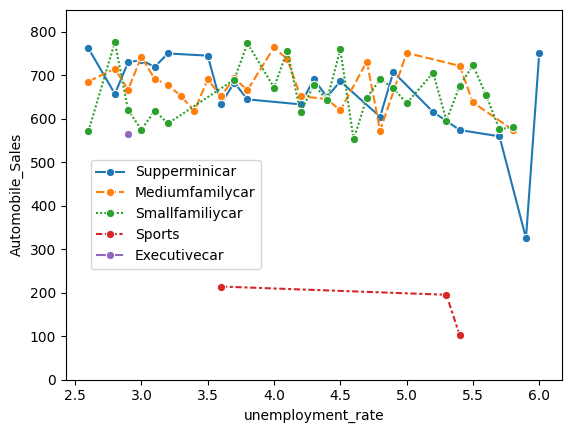

In [36]:
df_rec = df[df['Recession']==1]
sns.lineplot(data=df_rec, x='unemployment_rate', y='Automobile_Sales',
             hue='Vehicle_Type', style='Vehicle_Type', markers='o', err_style=None)
plt.ylim(0,850)
plt.legend(loc=(0.05,.3))